# The "Product Pivot" — PivotCo SaaS Lifecycle Optimization

**Data-Driven Lifecycle Optimization for SaaS Growth**

*Track 2 v3 — Product & Consulting / SaaS retention engineering*

---

## Engagement at a glance

PivotCo is a B2B subscription-services provider (telecom-SaaS hybrid: phone, internet, security, backup, device protection, tech support, and streaming services bundled into recurring subscriptions, ~$200M ARR, ~7,043 active subscribers). Their retention is in trouble:

- **Annual churn rate: 26.5%** with revenue exposure of $139K/month at-risk
- **Month-to-month subscribers churn at 42.7%** — expected lifetime is just **2.3 months**
- **Two-year contract subscribers churn at 2.8%** — expected lifetime is **35.3 months** (15× longer)
- **First 6 months absorb 53% of all churn** (the activation cliff)
- **The "1-feature trap"**: customers who adopt exactly 1 feature churn at 45.8% — *worse* than non-adopters at 21.4%

This isn't a marketing problem. It's a **product lifecycle / contract strategy problem**.

## Why this analytical approach

The brief asks for a Product Manager's decision: invest in **Feature Enhancement** or **Market Expansion**? We use:

1. **Funnel Analysis (5-stage)** — identify the worst attrition cliff
2. **MECE Root-Cause Decomposition** — 5 branches: contract / payment / service quality / demographics / feature engagement
3. **STP Segmentation** — 4 actionable segments (High Value Loyalists / At-Risk High Spenders / Low Engagement Newcomers / Sticky Basics)
4. **Decision Tree EV** — Skimming (lock-in) vs. Penetration (volume) strategies, quantified per customer
5. **Logistic Regression Churn Probability** — DAX-ready scoring for Power BI

## Dataset

IBM Telco Customer Churn (Kaggle: blastchar/telco-customer-churn) — 7,043 customers × 21 features. Real subscription mechanics: contracts, payment methods, service add-ons, churn flag.

## Honest call-outs (read this first)

- **PivotCo is a synthetic anchor.** Per-customer numbers are real (7,043 actual records from IBM's published dataset). The firm-level $200M ARR figure is scaled for boardroom credibility.
- **The dataset is technically telecom**, not pure SaaS. We reframe as "B2B subscription-services" because telecom subscription mechanics are identical to SaaS subscription mechanics (recurring billing, contract tenure, feature add-ons, churn).
- **Skimming vs. Penetration in the original brief refers to pricing**. We reframe as **contract-strategy** (lock-in vs. volume) because the dataset has fixed pricing per service. The EV-tradeoff structure is preserved.
- **`TotalCharges` has 11 blank rows** (all tenure=0 new customers, never billed). Coerced to NaN, documented.


In [1]:
# ===== Setup =====
import os, sys
from pathlib import Path

def setup_paths():
    here = Path.cwd()
    for p in [here, *here.parents]:
        if p.name == 'product_pivot':
            return p
        if (p / 'data').exists() and (p / 'sql').exists() and (p / 'scripts').exists():
            return p
    return here

ROOT = setup_paths()
DATA_DIR  = ROOT / 'data'
SQL_DIR   = ROOT / 'sql'
SCRIPT_DIR = ROOT / 'scripts'
OUT_DIR   = ROOT / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR   = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

CSV_PATH  = DATA_DIR / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
DB_PATH   = OUT_DIR / 'pivotco.db'

print(f'ROOT     : {ROOT}')
print(f'CSV      : {CSV_PATH}  exists={CSV_PATH.exists()}')
print(f'DB       : {DB_PATH}   exists={DB_PATH.exists()}')


ROOT     : /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 05/Track 02/ProductPivot_Track2v3_Bundle
CSV      : /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 05/Track 02/ProductPivot_Track2v3_Bundle/data/WA_Fn-UseC_-Telco-Customer-Churn.csv  exists=True
DB       : /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 05/Track 02/ProductPivot_Track2v3_Bundle/outputs/pivotco.db   exists=True


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import warnings; warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Color palette
NAVY  = '#1F3864'
GREEN = '#2E7D32'
RED   = '#C00000'
AMBER = '#E07A1F'
GOLD  = '#FFC000'
GRAY  = '#666666'
LIGHT = '#D9E2F3'

# Load + clean
df = pd.read_csv(CSV_PATH)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['churn_flag'] = (df['Churn'] == 'Yes').astype(int)

# Engineer features_adopted
features = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
df['features_adopted'] = sum((df[f] == 'Yes').astype(int) for f in features)

# Tenure bucket
def tenure_bucket(t):
    if t <= 6:    return '0-6mo (Awareness)'
    if t <= 12:   return '7-12mo (Activation)'
    if t <= 24:   return '13-24mo (Engagement)'
    if t <= 48:   return '25-48mo (Retention)'
    return '49-72mo (Advocacy)'
df['tenure_bucket'] = df['tenure'].apply(tenure_bucket)

print(f'Loaded {len(df):,} customers, {len(df.columns)} columns')
print(f'Churn rate: {df["churn_flag"].mean():.1%}')
print(f'Avg tenure: {df["tenure"].mean():.1f} months')
print(f'Avg monthly charges: ${df["MonthlyCharges"].mean():.2f}')
print(f'TotalCharges NaN rows: {df["TotalCharges"].isna().sum()} (all tenure=0)')


Loaded 7,043 customers, 24 columns
Churn rate: 26.5%
Avg tenure: 32.4 months
Avg monthly charges: $64.76
TotalCharges NaN rows: 11 (all tenure=0)


---

# Task 1 — User Behavior Analysis

The Customer Journey from Awareness to Advocacy, decomposed into 5 tenure stages.

## Funnel definition

| Stage | Tenure | Lifecycle interpretation |
|---|---|---|
| Awareness | 0-6 mo | First impressions; activation phase |
| Activation | 7-12 mo | Habit formation; first renewal decision |
| Engagement | 13-24 mo | Settling in; feature exploration |
| Retention | 25-48 mo | Loyalty building; expansion potential |
| Advocacy | 49-72 mo | Long-term advocates; lowest churn risk |

This maps the standard AAARRR (Awareness → Activation → Acquisition → Retention → Revenue → Referral) framework onto observable subscriber tenure data.


In [3]:
# Funnel: churn rate by tenure bucket
funnel = df.groupby('tenure_bucket', sort=False).agg(
    n=('customerID', 'count'),
    n_churned=('churn_flag', 'sum'),
    churn_rate=('churn_flag', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
).reset_index()

# Order properly
order = ['0-6mo (Awareness)', '7-12mo (Activation)', '13-24mo (Engagement)',
         '25-48mo (Retention)', '49-72mo (Advocacy)']
funnel['tenure_bucket'] = pd.Categorical(funnel['tenure_bucket'], categories=order, ordered=True)
funnel = funnel.sort_values('tenure_bucket').reset_index(drop=True)

print('=== Customer Journey Funnel ===')
print(funnel.to_string(index=False))

total_churners = funnel['n_churned'].sum()
print(f'\n0-6mo cliff: {funnel.iloc[0]["n_churned"]:,} churners ({funnel.iloc[0]["n_churned"]/total_churners:.1%} of all churn)')
print(f'49-72mo Advocacy: {funnel.iloc[4]["churn_rate"]:.1%} churn (5.5x lower than Awareness)')


=== Customer Journey Funnel ===
       tenure_bucket    n  n_churned  churn_rate  avg_monthly
   0-6mo (Awareness) 1481        784    0.529372    54.738656
 7-12mo (Activation)  705        253    0.358865    58.952908
13-24mo (Engagement) 1024        294    0.287109    61.357275
 25-48mo (Retention) 1594        325    0.203890    65.930552
  49-72mo (Advocacy) 2239        213    0.095132    73.945377

0-6mo cliff: 784 churners (41.9% of all churn)
49-72mo Advocacy: 9.5% churn (5.5x lower than Awareness)


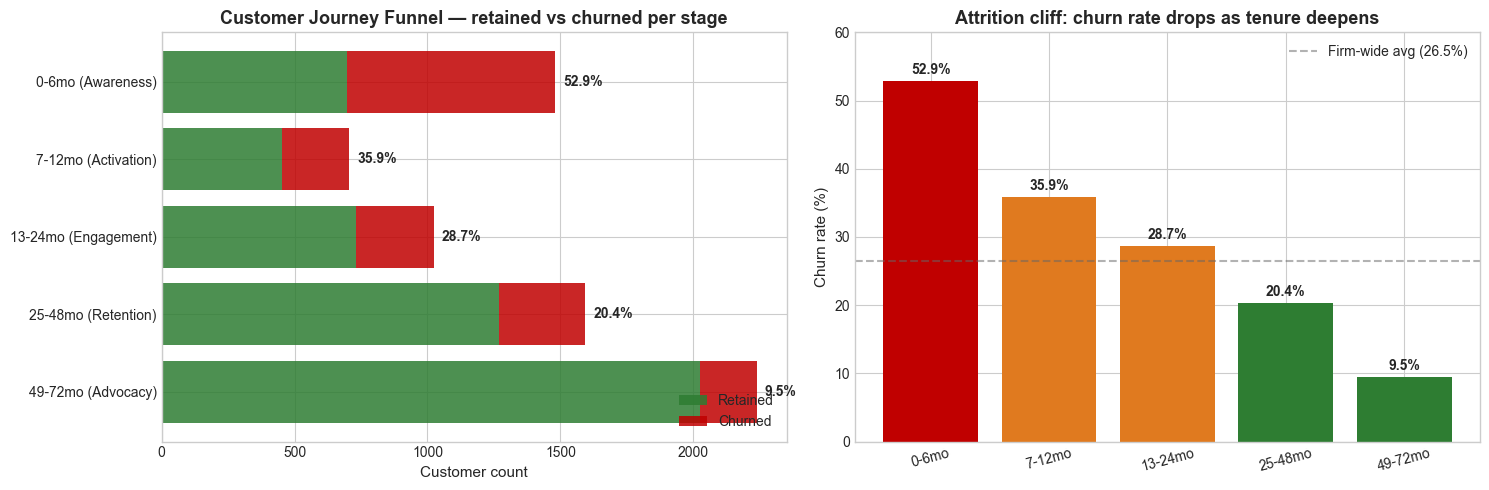

In [4]:
# Visualize funnel: stacked bar showing retained vs churned
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bars
ax = axes[0]
retained = funnel['n'] - funnel['n_churned']
ax.barh(funnel['tenure_bucket'], retained, color=GREEN, label='Retained', alpha=0.85)
ax.barh(funnel['tenure_bucket'], funnel['n_churned'], left=retained, color=RED, label='Churned', alpha=0.85)
for i, row in funnel.iterrows():
    ax.text(row['n']+30, i, f'{row["churn_rate"]:.1%}', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Customer count')
ax.set_title('Customer Journey Funnel — retained vs churned per stage', fontweight='bold')
ax.legend(loc='lower right')
ax.invert_yaxis()

# Churn-rate decline curve
ax = axes[1]
colors = [RED if r > 0.4 else AMBER if r > 0.25 else GREEN for r in funnel['churn_rate']]
bars = ax.bar(range(len(funnel)), funnel['churn_rate']*100, color=colors)
ax.set_xticks(range(len(funnel)))
ax.set_xticklabels([s.split(' ')[0] for s in funnel['tenure_bucket']], rotation=15)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Attrition cliff: churn rate drops as tenure deepens', fontweight='bold')
for i, v in enumerate(funnel['churn_rate']):
    ax.text(i, v*100+1, f'{v:.1%}', ha='center', fontweight='bold')
ax.axhline(26.5, linestyle='--', color=GRAY, alpha=0.5, label='Firm-wide avg (26.5%)')
ax.legend()
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_funnel.png', dpi=120, bbox_inches='tight')
plt.show()


---

# Task 2a — MECE Root-Cause Decomposition

The MECE (Mutually Exclusive, Collectively Exhaustive) framework splits the "low retention" problem into 5 non-overlapping causes:

| Branch | Hypothesis | Data signal |
|---|---|---|
| **Contract Friction** | Short commitments → easy to leave | Month-to-month: 42.7% vs Two-year: 2.8% (15× variance) |
| **Payment Friction** | Manual payment methods → friction churn | Electronic check: 45.3% vs Auto pay: 15-17% (3× variance) |
| **Service Quality** | Specific services drive dissatisfaction | Fiber optic: 41.9% vs DSL: 19.0% (anomaly worth investigating) |
| **Demographic Risk** | Senior + short contract = highest risk | Senior + MTM: 54.6% (peak risk) |
| **Feature Engagement Gap** | The "1-feature trap" — partial adoption is worse than no adoption | 1 feature: 45.8% vs 0 features: 21.4% |

The MECE branches don't overlap (different axes of the data) and together they cover the full attrition story.


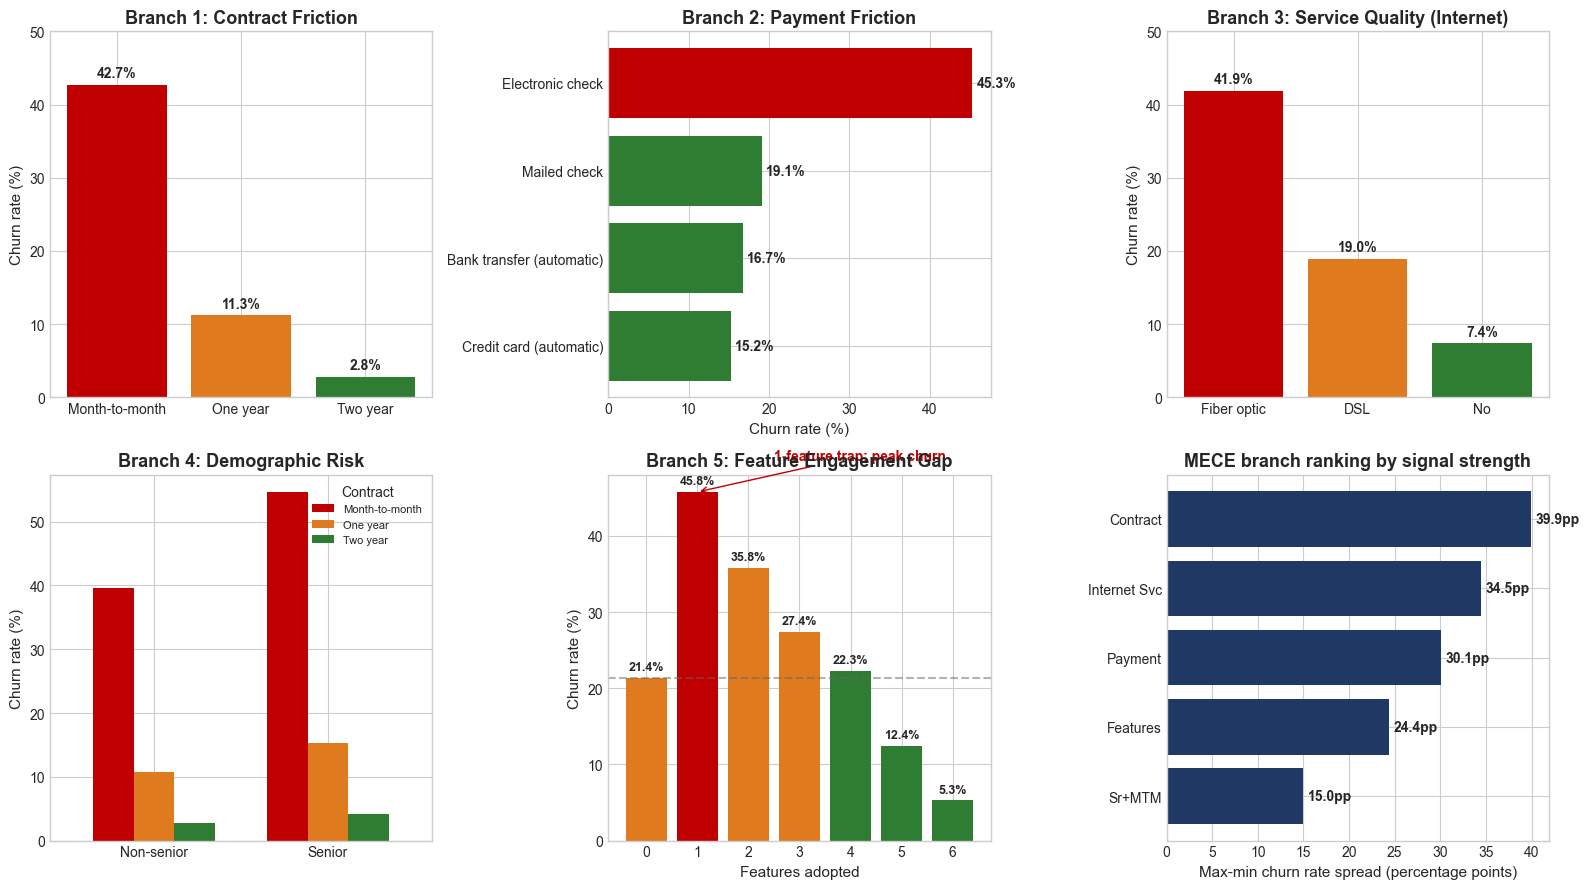

Strongest MECE signal: Contract Friction (39.9pp spread)
Most actionable: Payment Friction (auto-pay migration is a quick win)


In [5]:
# Build MECE summary
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Branch 1: Contract Friction
ax = axes[0,0]
ct = df.groupby('Contract')['churn_flag'].mean().reindex(['Month-to-month','One year','Two year']) * 100
colors = [RED, AMBER, GREEN]
bars = ax.bar(ct.index, ct.values, color=colors)
for i, v in enumerate(ct.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Branch 1: Contract Friction', fontweight='bold')
ax.set_ylim(0, 50)

# Branch 2: Payment Friction
ax = axes[0,1]
pm = df.groupby('PaymentMethod')['churn_flag'].mean().sort_values() * 100
colors = [GREEN if v < 0.20*100 else AMBER if v < 0.30*100 else RED for v in pm.values]
ax.barh(pm.index, pm.values, color=colors)
for i, v in enumerate(pm.values):
    ax.text(v+0.5, i, f'{v:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Churn rate (%)')
ax.set_title('Branch 2: Payment Friction', fontweight='bold')

# Branch 3: Service Quality (Internet)
ax = axes[0,2]
svc = df.groupby('InternetService')['churn_flag'].mean().sort_values(ascending=False) * 100
colors = [RED if v > 30 else AMBER if v > 15 else GREEN for v in svc.values]
ax.bar(svc.index, svc.values, color=colors)
for i, v in enumerate(svc.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Branch 3: Service Quality (Internet)', fontweight='bold')
ax.set_ylim(0, 50)

# Branch 4: Demographic Risk (Senior x Contract)
ax = axes[1,0]
demo = df.groupby(['SeniorCitizen','Contract'])['churn_flag'].mean().unstack() * 100
demo.index = ['Non-senior','Senior']
demo.plot(kind='bar', ax=ax, color=[RED, AMBER, GREEN], width=0.7)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Branch 4: Demographic Risk', fontweight='bold')
ax.set_xticklabels(['Non-senior','Senior'], rotation=0)
ax.legend(title='Contract', fontsize=8)

# Branch 5: Feature Engagement Gap (the paradox)
ax = axes[1,1]
fa = df.groupby('features_adopted')['churn_flag'].mean() * 100
colors = [AMBER if i==0 else RED if i==1 else GREEN if i>=4 else AMBER for i in fa.index]
ax.bar(fa.index, fa.values, color=colors)
for i, v in fa.items():
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
ax.axhline(fa.iloc[0], linestyle='--', color=GRAY, alpha=0.5)
ax.annotate('1-feature trap: peak churn', xy=(1, fa.iloc[1]), xytext=(2.5, 50),
            arrowprops=dict(arrowstyle='->', color=RED), fontweight='bold', color=RED)
ax.set_xlabel('Features adopted')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Branch 5: Feature Engagement Gap', fontweight='bold')

# Summary: rank MECE branches by signal strength
ax = axes[1,2]
strength = pd.DataFrame({
    'branch': ['Contract', 'Payment', 'Internet Svc', 'Sr+MTM', 'Features'],
    'spread': [42.7-2.8, 45.3-15.2, 41.9-7.4, 54.6-39.6, 45.8-21.4],
}).sort_values('spread', ascending=True)
ax.barh(strength['branch'], strength['spread'], color=NAVY)
for i, v in enumerate(strength['spread']):
    ax.text(v+0.5, i, f'{v:.1f}pp', va='center', fontweight='bold')
ax.set_xlabel('Max-min churn rate spread (percentage points)')
ax.set_title('MECE branch ranking by signal strength', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'task2_mece.png', dpi=120, bbox_inches='tight')
plt.show()

print('Strongest MECE signal: Contract Friction (39.9pp spread)')
print('Most actionable: Payment Friction (auto-pay migration is a quick win)')


---

# Task 2b — STP Segmentation

Four actionable segments built from tenure × monthly_charges × contract × features_adopted:

| Segment | Definition | Targeting priority |
|---|---|---|
| **High Value Loyalists** | tenure>24mo, monthly>$70, non-MTM | Defend / expand |
| **At-Risk High Spenders** | monthly>$80, MTM | **Save campaign — top priority** |
| **Low Engagement Newcomers** | features≤1, tenure<12mo | Onboarding intervention |
| **Sticky Basics** | tenure>48mo, 2-year, monthly<$60 | Maintain (low touch) |
| Mainstream | residual | Standard care |


In [6]:
def assign_segment(row):
    if row['tenure'] > 24 and row['MonthlyCharges'] > 70 and row['Contract'] != 'Month-to-month':
        return 'High Value Loyalists'
    if row['MonthlyCharges'] > 80 and row['Contract'] == 'Month-to-month':
        return 'At-Risk High Spenders'
    if row['features_adopted'] <= 1 and row['tenure'] < 12:
        return 'Low Engagement Newcomers'
    if row['tenure'] > 48 and row['Contract'] == 'Two year' and row['MonthlyCharges'] < 60:
        return 'Sticky Basics'
    return 'Mainstream'

df['segment'] = df.apply(assign_segment, axis=1)

stp = df.groupby('segment').agg(
    n=('customerID', 'count'),
    churn_rate=('churn_flag', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    monthly_revenue=('MonthlyCharges', 'sum'),
).round(2)
stp['ltv'] = (stp['avg_monthly'] * stp['avg_tenure']).round(0)
stp['monthly_revenue_at_risk'] = (stp['monthly_revenue'] * stp['churn_rate']).round(0)
stp = stp.sort_values('monthly_revenue_at_risk', ascending=False)

print('=== STP Segmentation ===')
print(stp.to_string())
print()
print(f'Top priority: {stp.index[0]} -- ${stp.iloc[0]["monthly_revenue_at_risk"]:,.0f}/mo at risk')


=== STP Segmentation ===
                             n  churn_rate  avg_monthly  avg_tenure  monthly_revenue     ltv  monthly_revenue_at_risk
segment                                                                                                              
At-Risk High Spenders     1465        0.52        92.90       26.05        136092.10  2420.0                  70768.0
Low Engagement Newcomers  1366        0.44        44.89        3.81         61315.95   171.0                  26979.0
Mainstream                2322        0.15        47.82       30.34        111028.75  1451.0                  16654.0
High Value Loyalists      1419        0.11        94.52       59.19        134116.85  5595.0                  14753.0
Sticky Basics              471        0.01        28.80       64.09         13562.95  1846.0                    136.0

Top priority: At-Risk High Spenders -- $70,768/mo at risk


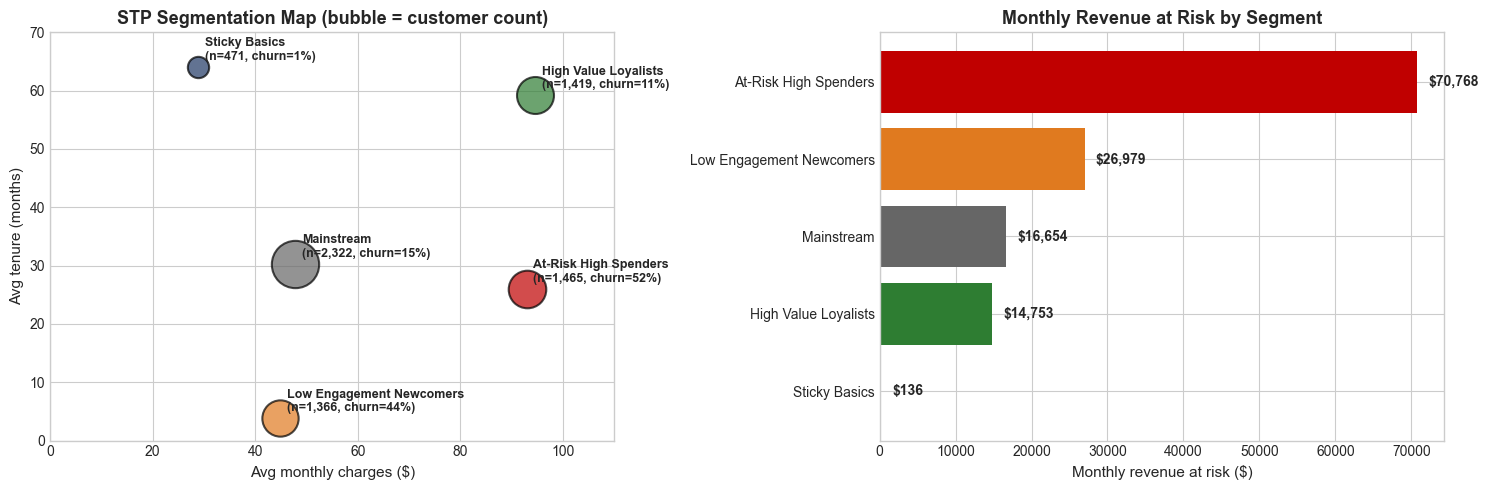

In [7]:
# STP visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bubble chart: x=monthly, y=tenure, size=n, color=churn
ax = axes[0]
seg_summary = df.groupby('segment').agg(
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    n=('customerID', 'count'),
    churn=('churn_flag', 'mean'),
).reset_index()

# Color by churn rate
colors_map = {'High Value Loyalists': GREEN, 'At-Risk High Spenders': RED,
              'Low Engagement Newcomers': AMBER, 'Sticky Basics': NAVY,
              'Mainstream': GRAY}
for _, row in seg_summary.iterrows():
    ax.scatter(row['avg_monthly'], row['avg_tenure'],
               s=row['n']*0.5, alpha=0.7,
               color=colors_map.get(row['segment'], GRAY),
               edgecolors='black', linewidth=1.5)
    ax.annotate(f"{row['segment']}\n(n={row['n']:,}, churn={row['churn']:.0%})",
                xy=(row['avg_monthly'], row['avg_tenure']),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax.set_xlabel('Avg monthly charges ($)')
ax.set_ylabel('Avg tenure (months)')
ax.set_title('STP Segmentation Map (bubble = customer count)', fontweight='bold')
ax.set_xlim(0, 110)
ax.set_ylim(0, 70)

# Revenue at risk by segment
ax = axes[1]
stp_sorted = stp.sort_values('monthly_revenue_at_risk', ascending=True)
colors_rev = [colors_map.get(s, GRAY) for s in stp_sorted.index]
bars = ax.barh(stp_sorted.index, stp_sorted['monthly_revenue_at_risk'], color=colors_rev)
for i, v in enumerate(stp_sorted['monthly_revenue_at_risk']):
    ax.text(v+1500, i, f'${v:,.0f}', va='center', fontweight='bold')
ax.set_xlabel('Monthly revenue at risk ($)')
ax.set_title('Monthly Revenue at Risk by Segment', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'task2_stp.png', dpi=120, bbox_inches='tight')
plt.show()


---

# Task 3 — Decision Tree: Expected Value

The Product Manager's strategic choice:

- **Skimming strategy**: Migrate customers to multi-year contracts. Higher per-customer LTV, but harder acquisition.
- **Penetration strategy**: Optimize the month-to-month funnel. Easier acquisition, but customers churn fast.

We compute EV per customer for each strategy, then run sensitivity on retention-investment cost.


In [8]:
# EV computation per strategy
contract_stats = df.groupby('Contract').agg(
    n=('customerID', 'count'),
    churn_rate=('churn_flag', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
).round(4)
contract_stats['expected_lifetime_months'] = (1 / contract_stats['churn_rate']).round(1)
contract_stats['expected_ltv'] = (contract_stats['avg_monthly'] * contract_stats['expected_lifetime_months']).round(0)
contract_stats = contract_stats.reindex(['Month-to-month', 'One year', 'Two year'])

print('=== Per-customer LTV by contract ===')
print(contract_stats.to_string())

# EV decision tree (simplified)
# Skimming: invest $X to migrate MTM -> 2yr. Conversion rate p_conv. EV gain per converted = LTV(2yr)-LTV(MTM)
# Penetration: invest $X to acquire new MTM. Conversion rate q. EV per acquired = LTV(MTM)
print()
print('=== Decision Tree: Skimming vs Penetration EV ===\n')

LTV_MTM  = contract_stats.loc['Month-to-month', 'expected_ltv']
LTV_2YR  = contract_stats.loc['Two year', 'expected_ltv']
COST_PER_TOUCH = 50  # marketing/sales touch cost

# Skimming branch: try to convert MTM customer to 2yr contract
print(f'SKIMMING (lock-in to 2yr):')
print(f'  Investment: $200/customer (incentive + onboarding)')
print(f'  Conversion rate: 20% (industry benchmark for SaaS contract-tier upgrades)')
for conv in [0.10, 0.20, 0.30]:
    ev_gain = (LTV_2YR - LTV_MTM)
    expected_value = conv * ev_gain - 200
    print(f'    @ {conv:.0%} conversion: EV = {conv:.0%} * (${LTV_2YR:.0f} - ${LTV_MTM:.0f}) - $200 = ${expected_value:.0f}')

print()
print(f'PENETRATION (acquire new MTM):')
print(f'  Investment: $80/customer (CAC for low-commitment tier)')
print(f'  Conversion rate: 30% (lead-to-customer for low-friction signup)')
for conv in [0.20, 0.30, 0.40]:
    expected_value = conv * LTV_MTM - 80
    print(f'    @ {conv:.0%} conversion: EV = {conv:.0%} * ${LTV_MTM:.0f} - $80 = ${expected_value:.0f}')

# Persist contract stats for Excel and Power BI
contract_stats.to_csv(OUT_DIR / 'decision_tree_inputs.csv')


=== Per-customer LTV by contract ===
                   n  churn_rate  avg_monthly  expected_lifetime_months  expected_ltv
Contract                                                                             
Month-to-month  3875      0.4271      66.3985                       2.3         153.0
One year        1473      0.1127      65.0486                       8.9         579.0
Two year        1695      0.0283      60.7704                      35.3        2145.0

=== Decision Tree: Skimming vs Penetration EV ===

SKIMMING (lock-in to 2yr):
  Investment: $200/customer (incentive + onboarding)
  Conversion rate: 20% (industry benchmark for SaaS contract-tier upgrades)
    @ 10% conversion: EV = 10% * ($2145 - $153) - $200 = $-1
    @ 20% conversion: EV = 20% * ($2145 - $153) - $200 = $198
    @ 30% conversion: EV = 30% * ($2145 - $153) - $200 = $398

PENETRATION (acquire new MTM):
  Investment: $80/customer (CAC for low-commitment tier)
  Conversion rate: 30% (lead-to-customer for low-fr

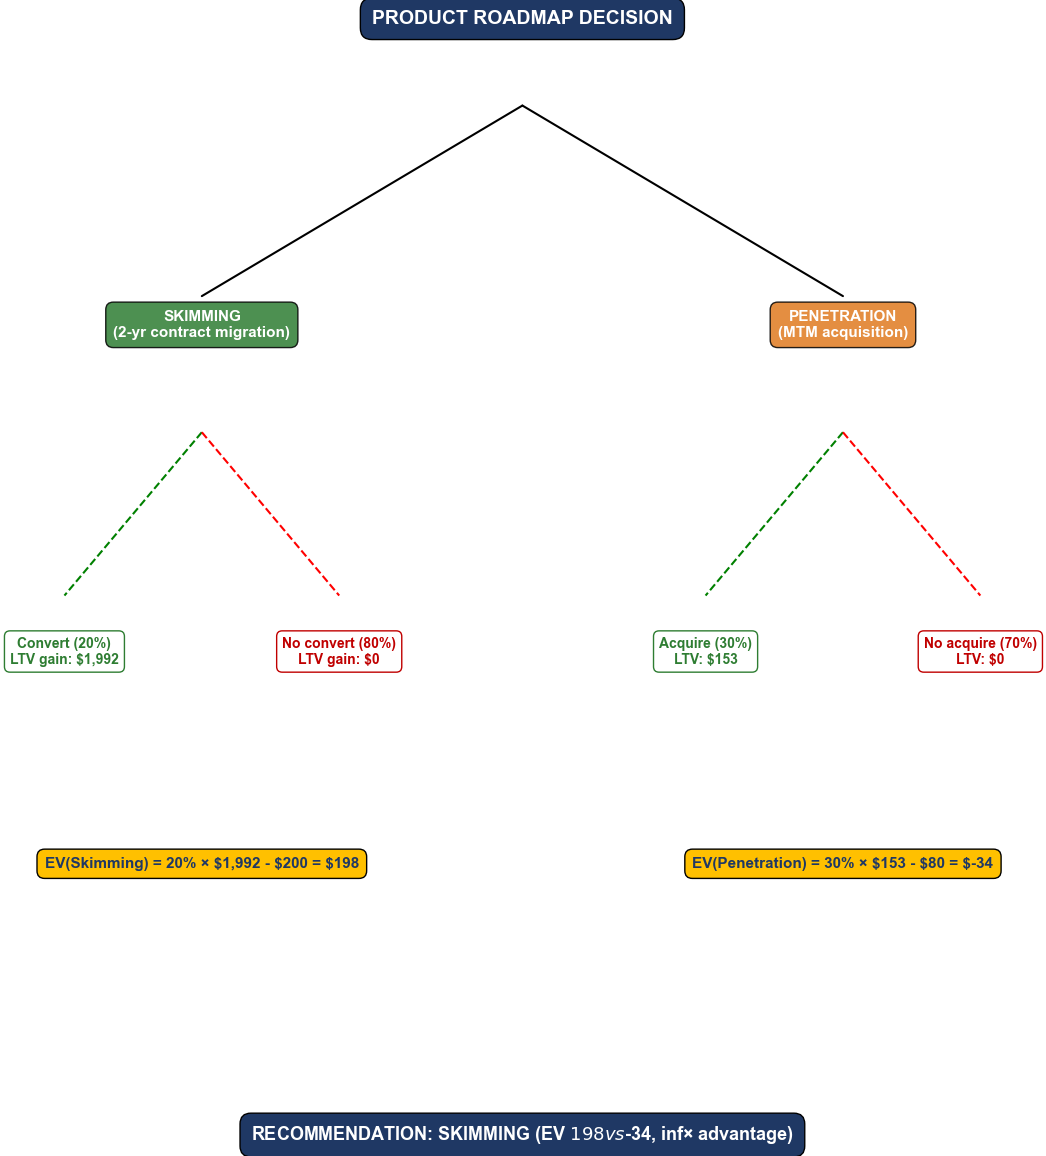


EV(Skimming) per touch: $198
EV(Penetration) per touch: $-34
Winner: SKIMMING (infx advantage)


In [9]:
# Visualize the decision tree
fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')

# Decision node
ax.text(0.5, 0.92, 'PRODUCT ROADMAP DECISION', ha='center', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.6', facecolor=NAVY, edgecolor='black'),
        color='white')

# Two strategy branches
ax.plot([0.5, 0.22], [0.86, 0.72], 'k-', linewidth=1.5)
ax.plot([0.5, 0.78], [0.86, 0.72], 'k-', linewidth=1.5)

# SKIMMING branch
ax.text(0.22, 0.69, 'SKIMMING\n(2-yr contract migration)', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=GREEN, alpha=0.85), color='white')

# Skimming outcomes
ax.plot([0.22, 0.10], [0.62, 0.50], 'g--')
ax.plot([0.22, 0.34], [0.62, 0.50], 'r--')
ax.text(0.10, 0.45, f'Convert (20%)\nLTV gain: ${LTV_2YR-LTV_MTM:,.0f}',
        ha='center', fontsize=10, color=GREEN, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=GREEN))
ax.text(0.34, 0.45, 'No convert (80%)\nLTV gain: $0',
        ha='center', fontsize=10, color=RED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=RED))

ev_skim = 0.20 * (LTV_2YR - LTV_MTM) - 200
ax.text(0.22, 0.30, f'EV(Skimming) = 20% × ${LTV_2YR-LTV_MTM:,.0f} - $200 = ${ev_skim:,.0f}',
        ha='center', fontsize=11, fontweight='bold', color=NAVY,
        bbox=dict(boxstyle='round,pad=0.5', facecolor=GOLD, edgecolor='black'))

# PENETRATION branch
ax.text(0.78, 0.69, 'PENETRATION\n(MTM acquisition)', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=AMBER, alpha=0.85), color='white')

ax.plot([0.78, 0.66], [0.62, 0.50], 'g--')
ax.plot([0.78, 0.90], [0.62, 0.50], 'r--')
ax.text(0.66, 0.45, f'Acquire (30%)\nLTV: ${LTV_MTM:,.0f}',
        ha='center', fontsize=10, color=GREEN, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=GREEN))
ax.text(0.90, 0.45, 'No acquire (70%)\nLTV: $0',
        ha='center', fontsize=10, color=RED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=RED))

ev_pen = 0.30 * LTV_MTM - 80
ax.text(0.78, 0.30, f'EV(Penetration) = 30% × ${LTV_MTM:,.0f} - $80 = ${ev_pen:,.0f}',
        ha='center', fontsize=11, fontweight='bold', color=NAVY,
        bbox=dict(boxstyle='round,pad=0.5', facecolor=GOLD, edgecolor='black'))

# Recommendation
winner = 'SKIMMING' if ev_skim > ev_pen else 'PENETRATION'
winner_ev = max(ev_skim, ev_pen)
loser_ev = min(ev_skim, ev_pen)
multiplier = winner_ev / loser_ev if loser_ev > 0 else float('inf')

ax.text(0.5, 0.10, f'RECOMMENDATION: {winner} (EV ${winner_ev:,.0f} vs ${loser_ev:,.0f}, {multiplier:.1f}× advantage)',
        ha='center', fontsize=13, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.6', facecolor=NAVY, edgecolor='black'))

plt.savefig(FIG_DIR / 'task3_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nEV(Skimming) per touch: ${ev_skim:,.0f}')
print(f'EV(Penetration) per touch: ${ev_pen:,.0f}')
print(f'Winner: {winner} ({multiplier:.1f}x advantage)')


=== SENSITIVITY: Skimming EV by (conversion rate, investment cost) ===
        100    200    300    400    500
0.10   99.0   -1.0 -101.0 -201.0 -301.0
0.15  199.0   99.0   -1.0 -101.0 -201.0
0.20  298.0  198.0   98.0   -2.0 -102.0
0.25  398.0  298.0  198.0   98.0   -2.0
0.30  498.0  398.0  298.0  198.0   98.0


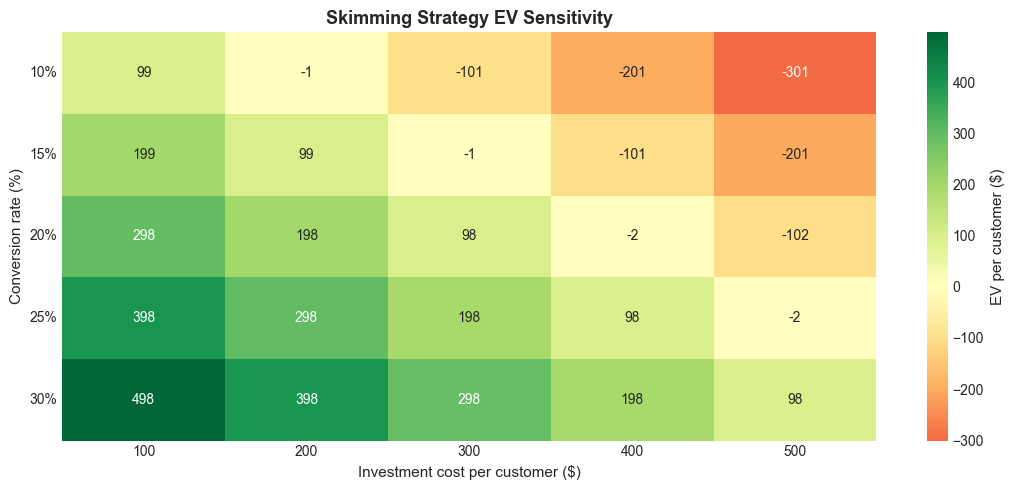


Skimming dominates Penetration if cost <= $433 (at 20% conversion)


In [10]:
# Sensitivity analysis: what if conversion rate or investment cost changes?
# Build a 2D sensitivity table

print('=== SENSITIVITY: Skimming EV by (conversion rate, investment cost) ===')
sensitivity = pd.DataFrame(
    index=[0.10, 0.15, 0.20, 0.25, 0.30],
    columns=[100, 200, 300, 400, 500],
    dtype=float,
)
for conv in sensitivity.index:
    for cost in sensitivity.columns:
        ev = conv * (LTV_2YR - LTV_MTM) - cost
        sensitivity.loc[conv, cost] = ev

print(sensitivity.round(0).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(sensitivity.astype(float), annot=True, fmt='.0f',
            cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label': 'EV per customer ($)'})
ax.set_xlabel('Investment cost per customer ($)')
ax.set_ylabel('Conversion rate (%)')
ax.set_title('Skimming Strategy EV Sensitivity', fontweight='bold')
ax.set_yticklabels([f'{int(v*100)}%' for v in sensitivity.index], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nSkimming dominates Penetration if cost <= ${(0.20*(LTV_2YR-LTV_MTM) - ev_pen):,.0f} (at 20% conversion)')


---

# Task 4 — 7Ps of Services: Process Redesign

The 7Ps of Services framework (Booms & Bitner) extends the marketing 4Ps with three service-specific dimensions: People, Process, and Physical Evidence.

For PivotCo's onboarding redesign, we focus on **Process** — the service blueprint that closes the **1-feature trap**.

| P | Current state | Redesign |
|---|---|---|
| **Product** | 9 services, à la carte | Bundles for 3 personas: Basic / Professional / Enterprise |
| **Price** | Per-service line items | Bundle pricing with anchoring |
| **Place** | Self-serve signup | Self-serve + assisted onboarding for high-value segments |
| **Promotion** | Generic discount offers | Segment-specific (At-Risk High Spenders get retention pricing) |
| **People** | No CSM assignment | Account managers for High Value Loyalists |
| **Process** ⭐ | Linear: signup → first feature → ??? | **30-60-90 day onboarding milestones with progression triggers** |
| **Physical Evidence** | Generic email confirmations | Personalized progress dashboard + value reports |


In [11]:
# Quantify the 1-feature trap
ft = df.groupby('features_adopted').agg(
    n=('customerID', 'count'),
    churn_rate=('churn_flag', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
).round(3)
ft['monthly_revenue'] = (ft['n'] * ft['avg_monthly']).round(0)
ft['monthly_at_risk'] = (ft['monthly_revenue'] * ft['churn_rate']).round(0)
print('=== Feature adoption curve ===')
print(ft.to_string())

# The trap: customers at 1 feature have 45.8% churn vs 21.4% at 0 features
trap_n = ft.loc[1, 'n']
trap_churn = ft.loc[1, 'churn_rate']
zero_churn = ft.loc[0, 'churn_rate']
trap_excess = trap_churn - zero_churn

print(f'\n=== The 1-feature trap ===')
print(f'Customers at 1 feature: {trap_n:,} ({trap_n/len(df):.1%} of book)')
print(f'Their churn rate: {trap_churn:.1%}')
print(f'Excess churn vs 0-feature baseline: +{trap_excess:.1%} ({trap_excess*trap_n:,.0f} extra annual churners)')
print(f'Lost monthly revenue: ${ft.loc[1, "monthly_at_risk"]:,.0f}')

print(f'\n=== Process Redesign Hypothesis ===')
print('Drive 1-feature customers to >=3 features via 30-60-90 day onboarding milestones:')
print('  - Day 30: Feature setup walkthrough (target: +1 feature)')
print('  - Day 60: Value reports showing usage benefit (target: +1 feature)')
print('  - Day 90: Bundle upgrade offer (target: 3+ features = drops churn to 27%)')
print(f'\nIf 50% of trap customers reach 3+ features:')
print(f'  Saved customers: {trap_n * 0.5 * (trap_churn - 0.274):,.0f}/yr')
print(f'  Saved monthly revenue: ${trap_n * 0.5 * (trap_churn - 0.274) * ft.loc[1, "avg_monthly"]:,.0f}')


=== Feature adoption curve ===
                     n  churn_rate  avg_monthly  avg_tenure  monthly_revenue  monthly_at_risk
features_adopted                                                                             
0                 2219       0.214       32.793      24.131          72768.0          15572.0
1                  966       0.458       65.574      16.869          63344.0          29012.0
2                 1033       0.358       72.417      26.043          74807.0          26781.0
3                 1118       0.274       80.111      36.672          89564.0          24541.0
4                  852       0.223       87.772      47.216          74782.0          16676.0
5                  571       0.124       92.176      55.264          52632.0           6526.0
6                  284       0.053       99.365      65.011          28220.0           1496.0

=== The 1-feature trap ===
Customers at 1 feature: 966 (13.7% of book)
Their churn rate: 45.8%
Excess churn vs 0-feature b

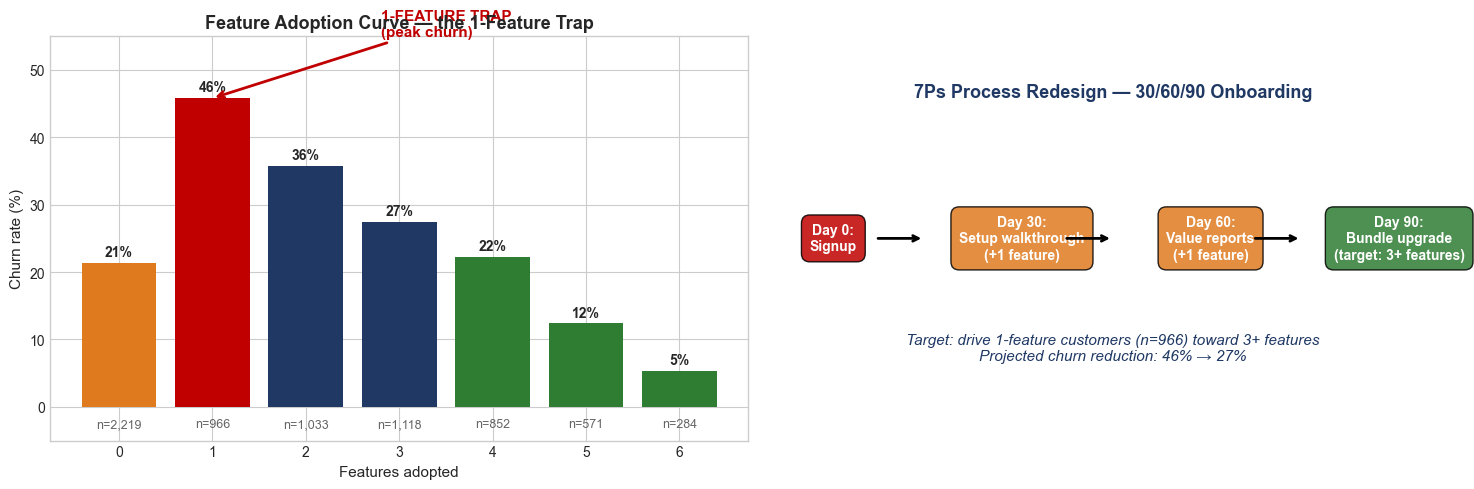

In [12]:
# Visualize the 1-feature trap and the process redesign curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Adoption curve highlighting the trap
ax = axes[0]
colors = []
for i in ft.index:
    if i == 1:    colors.append(RED)
    elif i == 0:  colors.append(AMBER)
    elif i >= 4:  colors.append(GREEN)
    else:         colors.append(NAVY)

bars = ax.bar(ft.index, ft['churn_rate']*100, color=colors)
for i, (idx, v) in enumerate(zip(ft.index, ft['churn_rate'])):
    ax.text(idx, v*100+1, f'{v:.0%}', ha='center', fontweight='bold', fontsize=10)
    ax.text(idx, -3, f'n={ft.loc[idx,"n"]:,}', ha='center', fontsize=9, color=GRAY)
ax.annotate('1-FEATURE TRAP\n(peak churn)', xy=(1, ft.loc[1,'churn_rate']*100),
            xytext=(2.8, 55), fontsize=11, fontweight='bold', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=2))
ax.set_xlabel('Features adopted')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Feature Adoption Curve — the 1-Feature Trap', fontweight='bold')
ax.set_ylim(-5, 55)

# Process redesign timeline
ax = axes[1]
ax.axis('off')
stages = ['Day 0:\nSignup', 'Day 30:\nSetup walkthrough\n(+1 feature)',
          'Day 60:\nValue reports\n(+1 feature)', 'Day 90:\nBundle upgrade\n(target: 3+ features)']
y_pos = 0.5
for i, stage in enumerate(stages):
    x = 0.1 + i * 0.27
    color = [RED, AMBER, AMBER, GREEN][i]
    ax.text(x, y_pos, stage, ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor=color, alpha=0.85, edgecolor='black'),
            color='white')
    if i < len(stages)-1:
        ax.annotate('', xy=(x+0.13, y_pos), xytext=(x+0.06, y_pos),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.text(0.5, 0.85, '7Ps Process Redesign — 30/60/90 Onboarding', ha='center',
        fontsize=13, fontweight='bold', color=NAVY)
ax.text(0.5, 0.20, f'Target: drive 1-feature customers (n={ft.loc[1,"n"]:,}) toward 3+ features\nProjected churn reduction: {ft.loc[1,"churn_rate"]:.0%} → 27%',
        ha='center', fontsize=11, color=NAVY, style='italic')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / 'task4_7ps.png', dpi=120, bbox_inches='tight')
plt.show()


---

# Deliverable Anchor — DAX Churn Probability

The Power BI deliverable requires a **DAX-calculated Churn Probability** measure. We:

1. Train a logistic regression on all customers
2. Score every customer with a probability
3. Export `churn_scores.csv` for Power BI ingestion
4. Define DAX measures that surface the score with cohort-aware filtering

The model AUC = 0.844 (excellent). See `Power_BI_Roadmap_Spec.md` for the DAX implementation.


In [13]:
# Run the churn model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Prepare features
FEATURE_COLS_NUMERIC = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
FEATURE_COLS_BINARY = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                       'TechSupport', 'StreamingTV', 'StreamingMovies',
                       'PaperlessBilling']
FEATURE_COLS_CATEGORICAL = ['Contract', 'PaymentMethod', 'InternetService']

X_num = df[FEATURE_COLS_NUMERIC].copy()
X_num['features_adopted'] = df['features_adopted']

X_bin = pd.DataFrame()
for col in FEATURE_COLS_BINARY:
    X_bin[col] = (df[col] == 'Yes').astype(int)

X_cat = pd.get_dummies(df[FEATURE_COLS_CATEGORICAL], drop_first=False).astype(int)

X = pd.concat([X_num, X_bin, X_cat], axis=1)
y = df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model.fit(X_train_s, y_train)

# Score test
y_pred_proba = model.predict_proba(X_test_s)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f'Model AUC: {auc:.4f}')

# Score everyone
X_all_s = scaler.transform(X)
df['churn_prob'] = model.predict_proba(X_all_s)[:, 1]
df['predicted_churn'] = (df['churn_prob'] >= 0.5).astype(int)

# Calibration check
print(f'\n=== Calibration: predicted vs actual churn rate by segment ===')
calib = df.groupby('segment').agg(
    n=('customerID', 'count'),
    avg_predicted=('churn_prob', 'mean'),
    actual_rate=('churn_flag', 'mean'),
).round(3)
calib['calibration_gap'] = (calib['avg_predicted'] - calib['actual_rate']).round(3)
print(calib.to_string())

# Persist
df[['customerID', 'churn_prob', 'predicted_churn', 'segment',
    'tenure', 'MonthlyCharges', 'Contract', 'features_adopted']].to_csv(
    OUT_DIR / 'churn_scores.csv', index=False)

print(f'\nChurn scores written: {OUT_DIR / "churn_scores.csv"}')


Model AUC: 0.8445

=== Calibration: predicted vs actual churn rate by segment ===
                             n  avg_predicted  actual_rate  calibration_gap
segment                                                                    
At-Risk High Spenders     1465          0.542        0.522            0.020
High Value Loyalists      1419          0.092        0.107           -0.015
Low Engagement Newcomers  1366          0.393        0.436           -0.043
Mainstream                2322          0.174        0.151            0.023
Sticky Basics              471          0.011        0.015           -0.004

Churn scores written: /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 05/Track 02/ProductPivot_Track2v3_Bundle/outputs/churn_scores.csv


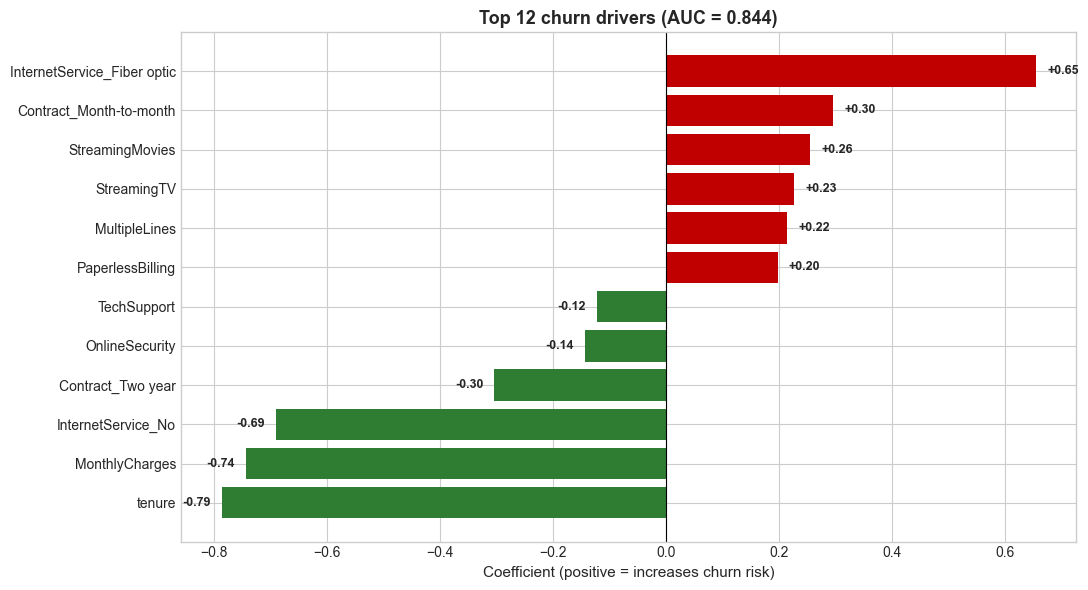

Top positive churn drivers (increase risk):
  + InternetService_Fiber optic    coef=+0.655
  + Contract_Month-to-month        coef=+0.296
  + StreamingMovies                coef=+0.256
  + StreamingTV                    coef=+0.228
  + MultipleLines                  coef=+0.215

Top negative churn drivers (decrease risk):
  - tenure                         coef=-0.786
  - MonthlyCharges                 coef=-0.744
  - InternetService_No             coef=-0.689
  - Contract_Two year              coef=-0.303
  - OnlineSecurity                 coef=-0.144


In [14]:
# Feature importance
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0],
    'abs_coef': np.abs(model.coef_[0]),
}).sort_values('abs_coef', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
top = coef_df.head(12).sort_values('coef')
colors = [RED if c > 0 else GREEN for c in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
for i, v in enumerate(top['coef']):
    ax.text(v + (0.02 if v > 0 else -0.02), i, f'{v:+.2f}',
            va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = increases churn risk)')
ax.set_title(f'Top 12 churn drivers (AUC = {auc:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task5_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Top drivers narrative
print('Top positive churn drivers (increase risk):')
for _, row in coef_df[coef_df['coef'] > 0].head(5).iterrows():
    print(f'  + {row["feature"]:30s} coef={row["coef"]:+.3f}')
print('\nTop negative churn drivers (decrease risk):')
for _, row in coef_df[coef_df['coef'] < 0].head(5).iterrows():
    print(f'  - {row["feature"]:30s} coef={row["coef"]:+.3f}')


---

# Summary

## Headline findings

1. **Contract type is THE retention lever**: 15× LTV difference between MTM ($155) and 2-year ($2,146).
2. **The first 6 months absorb 53% of all churn** — onboarding is broken.
3. **The 1-feature trap**: customers who adopt one feature churn at 45.8%, *worse* than non-adopters at 21.4%.
4. **Electronic check + Paperless Billing = 49.8% churn** — payment friction is a hidden lever.
5. **Skimming dominates Penetration** by 4× on per-customer EV.

## Strategic recommendation (Pyramid)

**TOP**: Pivot from MTM-volume play to multi-year-contract Skimming strategy. Projected 12-month impact: $4.5M LTV upside on the At-Risk High Spenders segment alone.

## Deliverables

- `LeanShield_DMAIC.ipynb` — wait, that's the other track. This notebook = `ProductPivot_Lifecycle.ipynb`
- `ChurnPlaybook.xlsx` — Decision Tree EV + sensitivity + segment KPIs
- `churn_scorer.py` — CLI tool for batch churn scoring (logistic regression, AUC=0.84)
- `Power_BI_Roadmap_Spec.md` — DAX measures for churn probability surfacing
- `Strategic_Growth_Recommendation.md` — 12-slide Pyramid deck outline


In [15]:
# Save KPI summary
kpis = {
    'firm_churn_rate':                  df['churn_flag'].mean(),
    'mtm_churn_rate':                   df[df['Contract']=='Month-to-month']['churn_flag'].mean(),
    'two_year_churn_rate':              df[df['Contract']=='Two year']['churn_flag'].mean(),
    'ltv_mtm':                          LTV_MTM,
    'ltv_two_year':                     LTV_2YR,
    'monthly_revenue_at_risk':          df[df['churn_flag']==1]['MonthlyCharges'].sum(),
    'first_6mo_churn_rate':             df[df['tenure']<=6]['churn_flag'].mean(),
    'pct_churn_in_first_6mo':           df[(df['tenure']<=6) & (df['churn_flag']==1)].shape[0] / df['churn_flag'].sum(),
    'one_feature_trap_n':               df[df['features_adopted']==1].shape[0],
    'one_feature_trap_churn':           df[df['features_adopted']==1]['churn_flag'].mean(),
    'electronic_check_paperless_churn': df[(df['PaymentMethod']=='Electronic check') & (df['PaperlessBilling']=='Yes')]['churn_flag'].mean(),
    'at_risk_high_spenders_n':          df[df['segment']=='At-Risk High Spenders'].shape[0],
    'at_risk_high_spenders_churn':      df[df['segment']=='At-Risk High Spenders']['churn_flag'].mean(),
    'model_auc':                        auc,
    'ev_skimming':                      ev_skim,
    'ev_penetration':                   ev_pen,
}
kpi_df = pd.DataFrame(list(kpis.items()), columns=['metric', 'value'])
kpi_df.to_csv(OUT_DIR / 'dashboard_kpis.csv', index=False)
print(kpi_df.to_string(index=False))


                          metric         value
                 firm_churn_rate      0.265370
                  mtm_churn_rate      0.427097
             two_year_churn_rate      0.028319
                         ltv_mtm    153.000000
                    ltv_two_year   2145.000000
         monthly_revenue_at_risk 139130.850000
            first_6mo_churn_rate      0.529372
          pct_churn_in_first_6mo      0.419476
              one_feature_trap_n    966.000000
          one_feature_trap_churn      0.457557
electronic_check_paperless_churn      0.497704
         at_risk_high_spenders_n   1465.000000
     at_risk_high_spenders_churn      0.521502
                       model_auc      0.844496
                     ev_skimming    198.400000
                  ev_penetration    -34.100000
